In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')                          # auth popup, once per session
RESULTS_DIR = '/content/drive/MyDrive/thesis_results'  # change name if you like
os.makedirs(RESULTS_DIR, exist_ok=True)
os.chdir(RESULTS_DIR)                                   # all relative saves now land here
print('Saving to:', os.getcwd())

Mounted at /content/drive
Saving to: /content/drive/MyDrive/thesis_results


In [2]:
# Imports

## Core libraries
import numpy as np
import matplotlib.pyplot as plt

## TensorFlow / Keras
import tensorflow as tf
import keras
from keras import ops, layers
from keras.callbacks import Callback
from keras.models import Sequential, Model
from keras.layers import Input, Conv2D, Dense


In [3]:
# Setting seeds

np.random.seed(1999)
tf.random.set_seed(1999)


In [4]:
# Loading the dataset

(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()

## Feature scaling (mapping pixel values to [0,1])
'''
This is used as neural network training via gradient descent is sensitive to the
scale of inputs (through activations a = Wx + b). This causes gradients to vanish
and makes the loss landscape poorly conditioned.
'''
x_train_full = x_train_full / 255.0
x_test = x_test / 255.0

''' Recalling our y values are our categories '''
y_train_full = keras.utils.to_categorical(y_train_full, 10)
y_test = keras.utils.to_categorical(y_test, 10)

## Setting up our validation dataset
n_val = int(0.2 * len(x_train_full))
perm = np.random.permutation(len(x_train_full))
val_idx, train_idx = perm[:n_val], perm[n_val:]
x_val, y_val = x_train_full[val_idx], y_train_full[val_idx]
x_train, y_train = x_train_full[train_idx], y_train_full[train_idx]

## Check
print(f"train: {x_train.shape} val: {x_val.shape} test: {x_test.shape}")


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
train: (40000, 32, 32, 3) val: (10000, 32, 32, 3) test: (10000, 32, 32, 3)


In [5]:
# Augmenting the dataset
'''
This involves creating new training examples by applying label preserving
transformations to existing examples e.g. flips, crops, scaling, colour jitter,
adding noise, ...
'''

'''
Applying three transformations in sequence, we pad the image with black 0s,
then randomly crop the newly padded image (so the model learns that a shifted
horse picture is still a horse), and then randomly mirroring the image from left
to right.
'''
augment = keras.Sequential([layers.ZeroPadding2D(padding=4),
                            layers.RandomCrop(32, 32),
                            layers.RandomFlip("horizontal")])

batch_size = 128

'''
This builds the full training data pipeline, where:
- The from_tensor_slices((x_train, y_train)) wraps the numpy arrays into a
  tf.data.Dataset that has image label pairs one at a time.
- For .shuffle(len(x_train)) - this shifts the entire dataset after each epoch.
- For .map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
  this applies the augmentation pipeline to each batch of images whilst leaving
  labels untouched. The training=True is important because RandomCrop and
  RandomFlip only apply their transformations during training. The
  num_parallel_calls=tf.data.AUTOTUNE lets TensorFlow decide how many batches to
  augment in parallel across CPU threads.
'''
train_ds = (tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(len(x_train)).batch(batch_size).map(lambda x, y: (augment(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE))

### Recalling that there is no augmentation for validation and test datasets
val_ds  = (tf.data.Dataset.from_tensor_slices((x_val,  y_val ))
           .batch(batch_size).prefetch(tf.data.AUTOTUNE))
test_ds = (tf.data.Dataset.from_tensor_slices((x_test, y_test))
           .batch(batch_size).prefetch(tf.data.AUTOTUNE))


In [6]:
# Residual block (no dropout)
'''
Here is the specification requirements for a single residual block (the repeating
unit in ResNet-20). Instead of learning the mapping between the input and the
output, we instead learn the difference between the input and the desired output
(the residual).

In this, the shortcut path passes the input unchanged (albeit with a channel
count change to match shapes at times). These two paths are added together for
a final ReLU.
'''

### We recall that a convolution slides a small window (a kernel/filter) across our grid.
### A single kernel produces one output grid (one channel). One kernel might learn to detect vertical edges, another colour gradients, and so on.
### We thus use 16 kernels simultaneously to produce an output with 16 channels.

class ResidualBlock(keras.layers.Layer):

    '''
    The init method constructs everything which doesn't fit into the other categories.
    In this, we construct the two convolutional layers and the ReLU activation.
    Everything here is created once and reused when the block processes an input.
    Projection is handled separately, as the input's channel count changes.
    '''
    def __init__(self, filters, stride=1, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.stride = stride

        ### The same padding here adds just enough padding at each convolution step so the output spatial dimensions match the input.
        ### The kernel initialiser establishes starting weights for the kernels such that they are not all zero (each kernel learns the same thing), too large (where activations explode), or too small (vanishing to zero).
        self.conv1 = layers.Conv2D(filters, 3, strides=stride, padding="same",
                                   kernel_regularizer=keras.regularizers.L2(1e-4),
                                   kernel_initializer="he_normal")

        ### Batch normalisation ensures each channel has a mean of 0 and a variance of 1.
        ### This is necessary for faster and more stable training as the weights update during training, causing our outputs to shift considerably (and calibrated to the old weights).
        ### The purpose of batch normalisation is to ensure a stable range of outputs.
        self.bn1 = layers.BatchNormalization()
        self.conv2 = layers.Conv2D(filters, 3, padding="same",
                                   kernel_regularizer=keras.regularizers.L2(1e-4),
                                   kernel_initializer="he_normal")
        self.bn2 = layers.BatchNormalization()
        self.relu = layers.Activation("relu")

    ### Going deeper into the network, we want to detect increasingly abstract features.
    ### We therefore downsample (have a bigger stride) as we detect combinations.
    ### We compensate for that by increasing the number of channels.

    '''
    The build method handles the projection shortcut (and handles shape-matching if needed).
    '''
    def build(self, input_shape):
        in_channels = input_shape[-1]

        if self.stride != 1 or in_channels != self.filters:
            self.proj = layers.Conv2D(self.filters, 1, strides=self.stride, padding="valid",
                                      kernel_regularizer=keras.regularizers.L2(1e-4),
                                      kernel_initializer="he_normal")
            self.bn_proj = layers.BatchNormalization()
        else:
            self.proj = None

        super().build(input_shape)

    '''
    The call method runs the actual forward pass of the model organising the
    split into the main convolutional path and the shortcut path, then summing
    them and applying ReLU.
    '''
    def call(self, x):
        if self.proj is not None:
            shortcut = self.bn_proj(self.proj(x))
        else:
            shortcut = x

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        return self.relu(out + shortcut)

    '''
    The get_config method enables serialisation so Keras can save/load the model.
    '''
    def get_config(self):
        config = super().get_config()
        config.update({"filters": self.filters,
                       "stride": self.stride})
        return config


In [7]:
# build_resnet20_vib — VIB alone variant (no SWAG / no weight uncertainty)
'''
The feature extractor follows the deterministic ResNet-20 specification above.
The only architectural change is after global average pooling: instead of sending
the feature vector directly to the classifier, we map it to the parameters of a
diagonal Gaussian bottleneck, sample z, and classify from z.

This is VIB alone. The weights are fixed after training; uncertainty at test time
comes only from repeatedly sampling the bottleneck representation z.
'''

class VIBSampling(keras.layers.Layer):

    """
    Reparameterisation layer for VIB.

    Given mu and log_var, sample z = mu + sigma * epsilon and add the VIB KL
    penalty beta * KL(q(z|x) || N(0, I)) to the model loss.
    """
    def __init__(self, beta=1e-3, **kwargs):
        super().__init__(**kwargs)
        self.beta = beta

    def call(self, inputs):
        mu, log_var = inputs
        eps = tf.random.normal(shape=tf.shape(mu), dtype=mu.dtype)
        z = mu + tf.exp(0.5 * log_var) * eps

        kl_per_example = -0.5 * tf.reduce_sum(
            1.0 + log_var - tf.square(mu) - tf.exp(log_var), axis=-1
        )
        self.add_loss(self.beta * tf.reduce_mean(kl_per_example))

        return z

    def get_config(self):
        config = super().get_config()
        config.update({"beta": self.beta})
        return config


def build_vib_resnet20(beta=1e-3, latent_dim=64):
    inputs = keras.Input(shape=(32, 32, 3))

    x = layers.Conv2D(16, 3, padding="same",
                      kernel_regularizer=keras.regularizers.L2(1e-4),
                      kernel_initializer="he_normal")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    for _ in range(3):
        x = ResidualBlock(16)(x)

    x = ResidualBlock(32, stride=2)(x)
    for _ in range(2):
        x = ResidualBlock(32)(x)

    x = ResidualBlock(64, stride=2)(x)
    for _ in range(2):
        x = ResidualBlock(64)(x)

    ### Global average pooling takes the block's output and turns it into a flat
    ### feature vector. In the deterministic version this went straight into the
    ### final dense layer; here it becomes the input to the VIB bottleneck.
    x = layers.GlobalAveragePooling2D()(x)

    z_mu = layers.Dense(latent_dim,
                        kernel_initializer="he_normal",
                        name="z_mu")(x)
    z_log_var = layers.Dense(latent_dim,
                             kernel_initializer="zeros",
                             bias_initializer="zeros",
                             name="z_log_var")(x)
    z = VIBSampling(beta=beta, name="vib_bottleneck")([z_mu, z_log_var])

    outputs = layers.Dense(10, kernel_initializer="he_normal")(z)

    return keras.Model(inputs, outputs)


In [8]:
# Building VIB-alone model

beta = 1e-3      # compression strength; useful alternatives: 1e-4, 1e-2
latent_dim = 64  # keep equal to the deterministic ResNet-20 pooled feature width

model = build_vib_resnet20(beta=beta, latent_dim=latent_dim)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        448 │ input_layer_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_block      │ (None, 32, 32,    │      4,768 │ activation[0][0]  │
│ (ResidualBlock)     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_block_1    │ (None, 32, 32,    │      4,768 │ residual_block[0… │
│ (ResidualBlock)     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_block_2    │ (None, 32, 32,    │      4,768 │ residual_block_1… │
│ (ResidualBlock)     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_block_3    │ (None, 16, 16,    │     14,816 │ residual_block_2… │
│ (ResidualBlock)     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_block_4    │ (None, 16, 16,    │     18,752 │ residual_block_3… │
│ (ResidualBlock)     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_block_5    │ (None, 16, 16,    │     18,752 │ residual_block_4… │
│ (ResidualBlock)     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_block_6    │ (None, 8, 8, 64)  │     58,304 │ residual_block_5… │
│ (ResidualBlock)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_block_7    │ (None, 8, 8, 64)  │     74,368 │ residual_block_6… │
│ (ResidualBlock)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_block_8    │ (None, 8, 8, 64)  │     74,368 │ residual_block_7… │
│ (ResidualBlock)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ residual_block_8… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mu (Dense)        │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vib_bottleneck      │ (None, 64)        │          0 │ z_mu[0][0],       │
│ (VIBSampling)       │                   │            │ z_log_var[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 283,146 (1.08 MB)

 Trainable params: 281,578 (1.07 MB)

 Non-trainable params: 1,568 (6.12 KB)

In [9]:
# Training VIB-alone model

'''
Step-wise learning-rate schedule: drop by 10x at epochs 100 and 150.
This is unchanged from the deterministic notebook so that the VIB-alone model
uses the same optimisation recipe.
'''
def lr_schedule(epoch, lr):
    if epoch in (100, 150):
        return lr * 0.1
    return lr


In [10]:
# Compiling

### This doesn't run any training or touch any data, but it configures the optimiser (how weights are updated), the loss function, and optionally any metrics we want to track.
### The VIB KL term is added inside the VIBSampling layer via self.add_loss(...), so the compile loss remains categorical cross-entropy.
model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.1, momentum=0.9),
              loss=keras.losses.CategoricalCrossentropy(from_logits=True),
              metrics=["categorical_accuracy"])


In [11]:
# Callbacks for checkpoints

callbacks = [keras.callbacks.ModelCheckpoint("vib_resnet20_best.weights.h5",
                                             monitor="val_loss",
                                             save_best_only=True,
                                             save_weights_only=True),
             keras.callbacks.LearningRateScheduler(lr_schedule, verbose=1)] # calls lr_schedule function each epoch to reduce learning rate


In [12]:
# Training

history = model.fit(train_ds,
                    epochs=200,
                    validation_data=val_ds,
                    callbacks=callbacks)


model.load_weights("vib_resnet20_best.weights.h5") # Loading best checkpoints

# Final evaluation on test set
# This is a single stochastic pass, so the MC evaluation cell below is the better
# number to report for the VIB predictive distribution.
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"\nSingle-sample test loss: {test_loss:.4f}  Single-sample test accuracy: {test_acc:.4f}")



Epoch 1: LearningRateScheduler setting learning rate to 0.10000000149011612.
Epoch 1/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 62ms/step - categorical_accuracy: 0.2789 - loss: 2.1750 - val_categorical_accuracy: 0.3051 - val_loss: 2.1401 - learning_rate: 0.1000

Epoch 2: LearningRateScheduler setting learning rate to 0.10000000149011612.
Epoch 2/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - categorical_accuracy: 0.4374 - loss: 1.7085 - val_categorical_accuracy: 0.3811 - val_loss: 2.1971 - learning_rate: 0.1000

Epoch 3: LearningRateScheduler setting learning rate to 0.10000000149011612.
Epoch 3/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - categorical_accuracy: 0.5548 - loss: 1.4250 - val_categorical_accuracy: 0.5682 - val_loss: 1.4469 - learning_rate: 0.1000

Epoch 4: LearningRateScheduler setting learning rate to 0.10000000149011612.
Epoch 4/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - categorical_accuracy: 0.6205 - loss: 1.2558 - val_categorical_accuracy: 0.5772 - val_loss: 1.4358

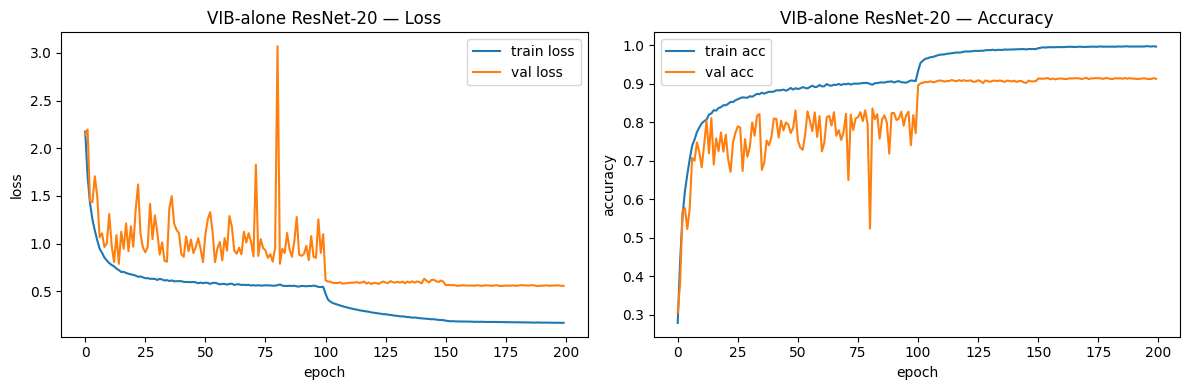

In [13]:
# Plotting training curves

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

## Plot 1
ax1.plot(history.history["loss"], label="train loss")
ax1.plot(history.history["val_loss"], label="val loss")
ax1.set_xlabel("epoch"); ax1.set_ylabel("loss")
ax1.set_title("VIB-alone ResNet-20 — Loss"); ax1.legend()

## Plot 2
ax2.plot(history.history["categorical_accuracy"], label="train acc")
ax2.plot(history.history["val_categorical_accuracy"], label="val acc")
ax2.set_xlabel("epoch"); ax2.set_ylabel("accuracy")
ax2.set_title("VIB-alone ResNet-20 — Accuracy"); ax2.legend()
plt.tight_layout(); plt.show()


In [14]:
# Loading SVHN as the out-of-distribution reference set
'''
Per the proposal §3.5, SVHN (street view of house numbers) is used as the
OOD test set. SVHN images are 32x32 colour photos like CIFAR-10, but of
digits, so a CIFAR-10 trained model should ideally report higher predictive
entropy on SVHN inputs than on its in-distribution CIFAR-10 test images.

We download the official SVHN test split (.mat) directly instead of using
tensorflow_datasets, which removes a flaky lazy-import dependency. The ~26k
images rescale to [0, 1] to match CIFAR-10 preprocessing; cached after the
first download.
'''
import os, urllib.request
from scipy.io import loadmat

svhn_path = "svhn_test_32x32.mat"
if not os.path.exists(svhn_path):
    urllib.request.urlretrieve(
        "http://ufldl.stanford.edu/housenumbers/test_32x32.mat", svhn_path)

mat = loadmat(svhn_path)
# mat["X"] has shape (32, 32, 3, N); move the sample axis to the front, rescale.
x_svhn = np.transpose(mat["X"], (3, 0, 1, 2)).astype("float32") / 255.0

print(f"SVHN OOD set: {x_svhn.shape}")


SVHN OOD set: (26032, 32, 32, 3)


In [15]:
# Loading CIFAR-10-C (common corruptions) as the in-distribution shift set
'''
Per the proposal §3.5, CIFAR-10-C (Hendrycks & Dietterich 2019) is the
corruption / covariate-shift evaluation set: the same 10 CIFAR-10 classes but
with algorithmic corruptions at graded severity. Unlike SVHN (far / semantic
OOD), these are in-domain-but-degraded inputs, so they probe a different kind
of uncertainty.

This patched version verifies the full CIFAR-10-C release, not just labels.npy.
The previous version could fail when labels.npy existed but corruption files
such as gaussian_noise.npy were missing after a partial extraction.
'''
import os, urllib.request, tarfile
import numpy as np

SEVERITY = globals().get("SEVERITY", 3)
CORRUPTIONS = globals().get("CORRUPTIONS", [
    "gaussian_noise", "shot_noise", "impulse_noise", "defocus_blur",
    "glass_blur", "motion_blur", "zoom_blur", "snow", "frost", "fog",
    "brightness", "contrast", "elastic_transform", "pixelate", "jpeg_compression",
])

CIFAR10C_ROOT = "CIFAR-10-C"
CIFAR10C_TAR = "CIFAR-10-C.tar"
CIFAR10C_URLS = [
    "https://zenodo.org/records/2535967/files/CIFAR-10-C.tar?download=1",
    "https://zenodo.org/record/2535967/files/CIFAR-10-C.tar",
]


def _required_cifar10c_files(corruptions=CORRUPTIONS):
    return ["labels.npy"] + [f"{corr}.npy" for corr in corruptions]


def _find_cifar10c_root(start=".", corruptions=CORRUPTIONS):
    """Return the directory that best looks like the extracted CIFAR-10-C root."""
    required = set(_required_cifar10c_files(corruptions))
    candidates = []

    for root, _dirs, files in os.walk(start):
        file_set = set(files)
        if "labels.npy" in file_set:
            score = len(required.intersection(file_set))
            candidates.append((score, root))

    if not candidates:
        return CIFAR10C_ROOT

    candidates.sort(reverse=True)
    return candidates[0][1]


def _missing_cifar10c_files(root, corruptions=CORRUPTIONS):
    return [
        filename
        for filename in _required_cifar10c_files(corruptions)
        if not os.path.exists(os.path.join(root, filename))
    ]


def _safe_extract_tar(tar, path="."):
    """Protect against path traversal before extracting the downloaded tar."""
    base = os.path.abspath(path)
    for member in tar.getmembers():
        member_path = os.path.abspath(os.path.join(path, member.name))
        if not (member_path == base or member_path.startswith(base + os.sep)):
            raise RuntimeError(f"Unsafe path in tar archive: {member.name}")
    tar.extractall(path)


def _download_cifar10c_tar(tar_path=CIFAR10C_TAR, urls=CIFAR10C_URLS):
    last_error = None
    for url in urls:
        try:
            print(f"Downloading CIFAR-10-C from {url}")
            urllib.request.urlretrieve(url, tar_path)
            return
        except Exception as exc:
            last_error = exc
            print(f"Download failed from {url}: {exc}")

    raise RuntimeError("Could not download CIFAR-10-C from any configured URL.") from last_error


def _extract_cifar10c_tar(tar_path=CIFAR10C_TAR):
    try:
        with tarfile.open(tar_path) as tar:
            _safe_extract_tar(tar, ".")
    except (tarfile.TarError, EOFError) as exc:
        print("Existing CIFAR-10-C tar is invalid or incomplete; re-downloading.")
        if os.path.exists(tar_path):
            os.remove(tar_path)
        _download_cifar10c_tar(tar_path)
        with tarfile.open(tar_path) as tar:
            _safe_extract_tar(tar, ".")


def load_cifar10c(severity=SEVERITY, corruptions=CORRUPTIONS, root=CIFAR10C_ROOT):
    """Download/extract CIFAR-10-C if needed, verify all files, then load one severity."""
    if not (1 <= severity <= 5):
        raise ValueError("CIFAR-10-C severity must be an integer from 1 to 5.")

    root = _find_cifar10c_root(".", corruptions)
    missing = _missing_cifar10c_files(root, corruptions)

    if missing:
        print(f"CIFAR-10-C is incomplete at '{root}'. Missing {len(missing)} file(s): {missing[:5]}")
        if not os.path.exists(CIFAR10C_TAR):
            print("CIFAR-10-C tar is not present; downloading it now (~2.9 GB).")
            _download_cifar10c_tar(CIFAR10C_TAR)
        else:
            print("CIFAR-10-C tar already exists; re-extracting it to repair the dataset.")

        _extract_cifar10c_tar(CIFAR10C_TAR)
        root = _find_cifar10c_root(".", corruptions)
        missing = _missing_cifar10c_files(root, corruptions)

    if missing:
        raise FileNotFoundError(
            "CIFAR-10-C is still incomplete after extraction. "
            f"Root checked: '{root}'. Missing files include: {missing[:10]}. "
            "Delete CIFAR-10-C and CIFAR-10-C.tar, then rerun this cell."
        )

    lo, hi = (severity - 1) * 10000, severity * 10000
    labels_full = np.load(os.path.join(root, "labels.npy"))
    labels_block = labels_full[lo:hi] if labels_full.shape[0] > 10000 else labels_full

    x_parts, y_parts = [], []
    for corr in corruptions:
        path = os.path.join(root, f"{corr}.npy")
        arr = np.load(path)[lo:hi]    # (10000, 32, 32, 3) uint8
        x_parts.append(arr)
        y_parts.append(labels_block)

    x_cifar10c = np.concatenate(x_parts, axis=0).astype("float32") / 255.0
    labels_cifar10c = np.concatenate(y_parts, axis=0).astype("int64")

    print(
        f"CIFAR-10-C set (severity {severity}, {len(corruptions)} corruptions): "
        f"{x_cifar10c.shape}, labels {labels_cifar10c.shape}"
    )
    print(f"CIFAR-10-C root: {root}")

    return x_cifar10c, labels_cifar10c


# Execute the load in this cell so Run all prepares CIFAR-10-C before prediction.
x_cifar10c, labels_cifar10c = load_cifar10c(SEVERITY, CORRUPTIONS)


CIFAR-10-C set (severity 3, 15 corruptions): (150000, 32, 32, 3), labels (150000,)
CIFAR-10-C root: ./CIFAR-10-C


In [16]:
# Generating predictions for the evaluation file
'''
This is the only output the downstream evaluation notebook needs from this
file. We produce softmax probabilities on:
  - the CIFAR-10 test set (in-distribution),
  - the SVHN test set (out-of-distribution),
and stash the true labels and the predicted classes alongside.

The VIB-alone model has stochasticity at the representation level only. The MC
axis below is therefore repeated bottleneck samples with fixed trained weights:
there is no SWAG posterior and no weight sampling in this notebook.
'''

# Guard: load CIFAR-10-C here if the dedicated loading cell was skipped.
# This prevents the results file from being saved without CIFAR-10-C outputs.
if "x_cifar10c" not in globals() or "labels_cifar10c" not in globals():
    print("CIFAR-10-C was not loaded before prediction; loading it now.")
    if "load_cifar10c" not in globals():
        import os, urllib.request, tarfile
        import numpy as np

        SEVERITY = globals().get("SEVERITY", 3)
        CORRUPTIONS = globals().get("CORRUPTIONS", [
            "gaussian_noise", "shot_noise", "impulse_noise", "defocus_blur",
            "glass_blur", "motion_blur", "zoom_blur", "snow", "frost", "fog",
            "brightness", "contrast", "elastic_transform", "pixelate", "jpeg_compression",
        ])

        CIFAR10C_ROOT = "CIFAR-10-C"
        CIFAR10C_TAR = "CIFAR-10-C.tar"
        CIFAR10C_URLS = [
            "https://zenodo.org/records/2535967/files/CIFAR-10-C.tar?download=1",
            "https://zenodo.org/record/2535967/files/CIFAR-10-C.tar",
        ]


        def _required_cifar10c_files(corruptions=CORRUPTIONS):
            return ["labels.npy"] + [f"{corr}.npy" for corr in corruptions]


        def _find_cifar10c_root(start=".", corruptions=CORRUPTIONS):
            """Return the directory that best looks like the extracted CIFAR-10-C root."""
            required = set(_required_cifar10c_files(corruptions))
            candidates = []

            for root, _dirs, files in os.walk(start):
                file_set = set(files)
                if "labels.npy" in file_set:
                    score = len(required.intersection(file_set))
                    candidates.append((score, root))

            if not candidates:
                return CIFAR10C_ROOT

            candidates.sort(reverse=True)
            return candidates[0][1]


        def _missing_cifar10c_files(root, corruptions=CORRUPTIONS):
            return [
                filename
                for filename in _required_cifar10c_files(corruptions)
                if not os.path.exists(os.path.join(root, filename))
            ]


        def _safe_extract_tar(tar, path="."):
            """Protect against path traversal before extracting the downloaded tar."""
            base = os.path.abspath(path)
            for member in tar.getmembers():
                member_path = os.path.abspath(os.path.join(path, member.name))
                if not (member_path == base or member_path.startswith(base + os.sep)):
                    raise RuntimeError(f"Unsafe path in tar archive: {member.name}")
            tar.extractall(path)


        def _download_cifar10c_tar(tar_path=CIFAR10C_TAR, urls=CIFAR10C_URLS):
            last_error = None
            for url in urls:
                try:
                    print(f"Downloading CIFAR-10-C from {url}")
                    urllib.request.urlretrieve(url, tar_path)
                    return
                except Exception as exc:
                    last_error = exc
                    print(f"Download failed from {url}: {exc}")

            raise RuntimeError("Could not download CIFAR-10-C from any configured URL.") from last_error


        def _extract_cifar10c_tar(tar_path=CIFAR10C_TAR):
            try:
                with tarfile.open(tar_path) as tar:
                    _safe_extract_tar(tar, ".")
            except (tarfile.TarError, EOFError) as exc:
                print("Existing CIFAR-10-C tar is invalid or incomplete; re-downloading.")
                if os.path.exists(tar_path):
                    os.remove(tar_path)
                _download_cifar10c_tar(tar_path)
                with tarfile.open(tar_path) as tar:
                    _safe_extract_tar(tar, ".")


        def load_cifar10c(severity=SEVERITY, corruptions=CORRUPTIONS, root=CIFAR10C_ROOT):
            """Download/extract CIFAR-10-C if needed, verify all files, then load one severity."""
            if not (1 <= severity <= 5):
                raise ValueError("CIFAR-10-C severity must be an integer from 1 to 5.")

            root = _find_cifar10c_root(".", corruptions)
            missing = _missing_cifar10c_files(root, corruptions)

            if missing:
                print(f"CIFAR-10-C is incomplete at '{root}'. Missing {len(missing)} file(s): {missing[:5]}")
                if not os.path.exists(CIFAR10C_TAR):
                    print("CIFAR-10-C tar is not present; downloading it now (~2.9 GB).")
                    _download_cifar10c_tar(CIFAR10C_TAR)
                else:
                    print("CIFAR-10-C tar already exists; re-extracting it to repair the dataset.")

                _extract_cifar10c_tar(CIFAR10C_TAR)
                root = _find_cifar10c_root(".", corruptions)
                missing = _missing_cifar10c_files(root, corruptions)

            if missing:
                raise FileNotFoundError(
                    "CIFAR-10-C is still incomplete after extraction. "
                    f"Root checked: '{root}'. Missing files include: {missing[:10]}. "
                    "Delete CIFAR-10-C and CIFAR-10-C.tar, then rerun this cell."
                )

            lo, hi = (severity - 1) * 10000, severity * 10000
            labels_full = np.load(os.path.join(root, "labels.npy"))
            labels_block = labels_full[lo:hi] if labels_full.shape[0] > 10000 else labels_full

            x_parts, y_parts = [], []
            for corr in corruptions:
                path = os.path.join(root, f"{corr}.npy")
                arr = np.load(path)[lo:hi]    # (10000, 32, 32, 3) uint8
                x_parts.append(arr)
                y_parts.append(labels_block)

            x_cifar10c = np.concatenate(x_parts, axis=0).astype("float32") / 255.0
            labels_cifar10c = np.concatenate(y_parts, axis=0).astype("int64")

            print(
                f"CIFAR-10-C set (severity {severity}, {len(corruptions)} corruptions): "
                f"{x_cifar10c.shape}, labels {labels_cifar10c.shape}"
            )
            print(f"CIFAR-10-C root: {root}")

            return x_cifar10c, labels_cifar10c

    x_cifar10c, labels_cifar10c = load_cifar10c(SEVERITY, CORRUPTIONS)

def predict_vib_mc(model, data, mc_samples=30, batch_size=128):
    all_probs = []

    for s in range(mc_samples):
        if isinstance(data, tf.data.Dataset):
            logits = model.predict(data, verbose=0)
        else:
            logits = model.predict(data, batch_size=batch_size, verbose=0)

        probs = tf.nn.softmax(logits, axis=-1).numpy()
        all_probs.append(probs)

        print(f"MC sample {s + 1:02d}/{mc_samples} complete")

    all_probs = np.stack(all_probs, axis=0)   # (M, N, 10)
    mean_probs = all_probs.mean(axis=0)       # (N, 10)

    return mean_probs, all_probs

n_mc_samples = 30

## In-distribution: CIFAR-10 test set
probs_test, all_probs_test = predict_vib_mc(model, test_ds, mc_samples=n_mc_samples)
preds_test  = np.argmax(probs_test, axis=1)
labels_test = np.argmax(y_test, axis=1)

print(f"MC-averaged test accuracy: {(preds_test == labels_test).mean():.4f}")

## Out-of-distribution: SVHN test set
probs_svhn, all_probs_svhn = predict_vib_mc(model, x_svhn, mc_samples=n_mc_samples, batch_size=128)

## In-distribution shift: CIFAR-10-C (severity 3, 15 corruptions)
probs_cifar10c, all_probs_cifar10c = predict_vib_mc(model, x_cifar10c, mc_samples=n_mc_samples, batch_size=128)

print(f"probs_test:         {probs_test.shape}")
print(f"all_probs_test:     {all_probs_test.shape}")
print(f"probs_svhn:         {probs_svhn.shape}")
print(f"all_probs_svhn:     {all_probs_svhn.shape}")
print(f"probs_cifar10c:     {probs_cifar10c.shape}")
print(f"all_probs_cifar10c: {all_probs_cifar10c.shape}")


MC sample 01/30 complete
MC sample 02/30 complete
MC sample 03/30 complete
MC sample 04/30 complete
MC sample 05/30 complete
MC sample 06/30 complete
MC sample 07/30 complete
MC sample 08/30 complete
MC sample 09/30 complete
MC sample 10/30 complete
MC sample 11/30 complete
MC sample 12/30 complete
MC sample 13/30 complete
MC sample 14/30 complete
MC sample 15/30 complete
MC sample 16/30 complete
MC sample 17/30 complete
MC sample 18/30 complete
MC sample 19/30 complete
MC sample 20/30 complete
MC sample 21/30 complete
MC sample 22/30 complete
MC sample 23/30 complete
MC sample 24/30 complete
MC sample 25/30 complete
MC sample 26/30 complete
MC sample 27/30 complete
MC sample 28/30 complete
MC sample 29/30 complete
MC sample 30/30 complete
MC-averaged test accuracy: 0.9120
MC sample 01/30 complete
MC sample 02/30 complete
MC sample 03/30 complete
MC sample 04/30 complete
MC sample 05/30 complete
MC sample 06/30 complete
MC sample 07/30 complete
MC sample 08/30 complete
MC sample 09/30 

In [17]:
# Saving raw outputs for the evaluation file
'''
Save format (shared across all benchmarks). The evaluation notebook will
load these by filename and produce ECE, reliability diagrams, OOD AUROC,
risk-coverage and uncertainty summaries.

Keys:
  model_name     - human-readable string identifier
  beta           - VIB compression strength used for training
  latent_dim     - bottleneck dimensionality
  n_mc_samples   - number of representation samples used at inference
  probs_test     - (N_test, 10)  mean predictive distribution on CIFAR-10 test
  labels_test    - (N_test,)     true labels (integer 0-9)
  preds_test     - (N_test,)     argmax of probs_test
  probs_svhn     - (N_svhn, 10)  mean predictive distribution on SVHN OOD
  all_probs_test - (M, N_test, 10) per-representation-sample probs
  all_probs_svhn - (M, N_svhn, 10) per-representation-sample probs

There is intentionally no weight-sample axis here. The MC axis is bottleneck /
representation stochasticity only.
'''
np.savez("vib_alone_results.npz",
         model_name="vib_alone",
         beta=beta,
         latent_dim=latent_dim,
         n_mc_samples=n_mc_samples,
         probs_test=probs_test,
         labels_test=labels_test,
         preds_test=preds_test,
         probs_svhn=probs_svhn,
         probs_cifar10c=probs_cifar10c,
         labels_cifar10c=labels_cifar10c,
         cifar10c_severity=SEVERITY,
         all_probs_test=all_probs_test,
         all_probs_svhn=all_probs_svhn,
         all_probs_cifar10c=all_probs_cifar10c,
         rep_probs_test=all_probs_test,
         rep_probs_svhn=all_probs_svhn,
         rep_probs_cifar10c=all_probs_cifar10c)

print("Saved vib_alone_results.npz")


Saved vib_alone_results.npz
